#### Import and data processing


In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

In [13]:
stdf = pd.read_csv("student.csv")
stdf.describe()

,Statistic,Algebra,Geometry,Geography,Biology,Physics,Chemistry,Earth Sciences,Literature,Writing,Speech,Economics,Programming
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,9.345393,9.466067,19.494944,3.618539,1.590899,99.741573,5.058090,11.475562,2.029270,0.957449,2.611685,746.893258
std,0.811827,4.468584,1.097376,3.339564,1.244533,0.572359,14.282484,2.318286,3.129255,0.998859,0.228572,0.709990,314.907474
min,11.030000,2.960000,5.440000,10.600000,1.300000,0.410000,70.000000,1.280000,4.900000,0.340000,0.480000,1.270000,278.000000
25%,12.362500,6.410000,8.840000,17.200000,2.700000,1.250000,88.000000,3.220000,8.712500,1.205000,0.782500,1.937500,500.500000
50%,13.050000,7.460000,9.440000,19.500000,3.400000,1.555000,98.000000,4.690000,11.775000,2.135000,0.965000,2.780000,673.500000
75%,13.677500,12.330000,10.230000,21.500000,4.375000,1.950000,107.000000,6.200000,14.000000,2.875000,1.120000,3.170000,985.000000
max,14.830000,23.200000,12.920000,30.000000,6.600000,3.580000,162.000000,13.000000,19.400000,5.080000,1.710000,4.000000,1680.000000


In [14]:
stdf.head()

,Statistic,Algebra,Geometry,Geography,Biology,Physics,Chemistry,Earth Sciences,Literature,Writing,Speech,Economics,Programming
0,14.23,6.84,9.72,15.6,2.8,2.29,127,5.64,14.00,3.06,1.04,3.92,1065
1,13.20,7.12,8.56,11.2,2.6,1.28,100,4.38,13.25,2.76,1.05,3.40,1050
2,13.16,9.44,10.68,18.6,3.0,2.81,101,5.68,14.00,3.24,1.03,3.17,1185
3,14.37,7.80,10.00,16.8,2.4,2.18,113,7.80,19.25,3.49,0.86,3.45,1480
4,13.24,10.36,11.48,21.0,3.9,1.82,118,4.32,14.00,2.69,1.04,2.93,735


In [15]:
scaler = StandardScaler()

norm_df = pd.DataFrame(scaler.fit_transform(stdf), columns=stdf.columns)

norm_df.head()

,Statistic,Algebra,Geometry,Geography,Biology,Physics,Chemistry,Earth Sciences,Literature,Writing,Speech,Economics,Programming
0,1.518613,-0.562250,0.232053,-1.169593,-0.659563,1.224884,1.913905,0.251717,0.808997,1.034819,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,-0.820719,-0.544721,0.018145,-0.293321,0.568648,0.733629,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,-0.498407,2.135968,0.088358,0.269020,0.808997,1.215533,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,-0.981875,1.032155,0.930918,1.186068,2.491446,1.466525,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,0.226796,0.401404,1.281985,-0.319276,0.808997,0.663351,0.362177,0.449601,-0.037874


In [16]:
norm_df.describe()

,Statistic,Algebra,Geometry,Geography,Biology,Physics,Chemistry,Earth Sciences,Literature,Writing,Speech,Economics,Programming
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-6.386901e-16,-1.197544e-16,-3.991813e-17,1.796316e-16,1.596725e-16,-3.991813e-16,1.995907e-16,3.193450e-16,-1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-1.868234e+00,-2.069034e+00,-2.088255e+00,-1.634288e+00,-2.107246e+00,-1.695971e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-7.401412e-01,-5.972835e-01,-8.244151e-01,-7.951025e-01,-8.854682e-01,-8.275393e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.760948e-01,-6.289785e-02,-1.222817e-01,-1.592246e-01,9.595986e-02,1.061497e-01,3.312687e-02,2.377348e-01,-2.337204e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,6.095413e-01,6.291754e-01,5.096384e-01,4.939560e-01,8.089974e-01,8.490851e-01,7.131644e-01,7.885875e-01,7.582494e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,2.402403e+00,3.485073e+00,4.371372e+00,3.435432e+00,2.539515e+00,3.062832e+00,3.301694e+00,1.960915e+00,2.971473e+00


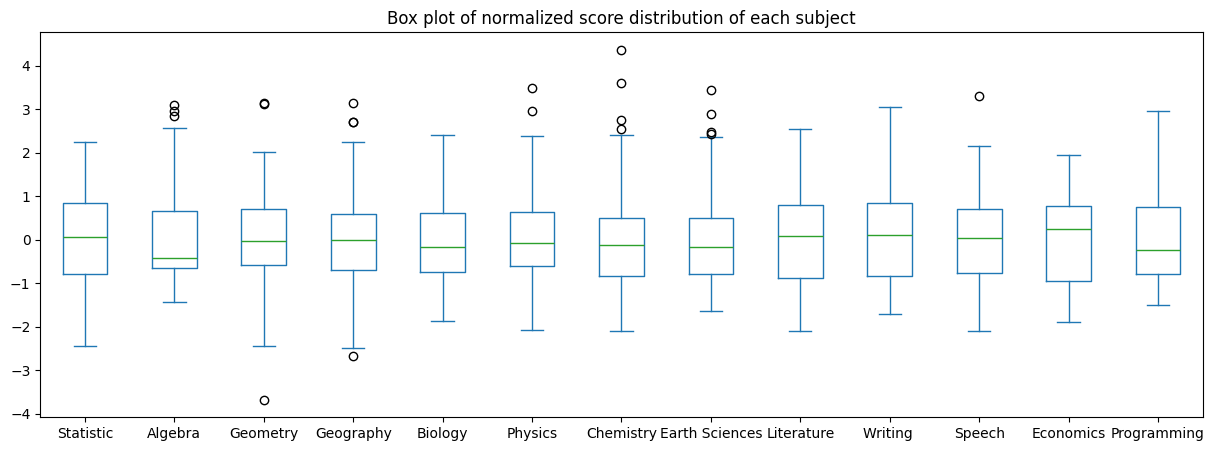

In [17]:
norm_df.plot(kind="box", figsize=(15,5))
plt.title("Box plot of normalized score distribution of each subject")
plt.show()

In [18]:
norm_df.shape

(178, 13)

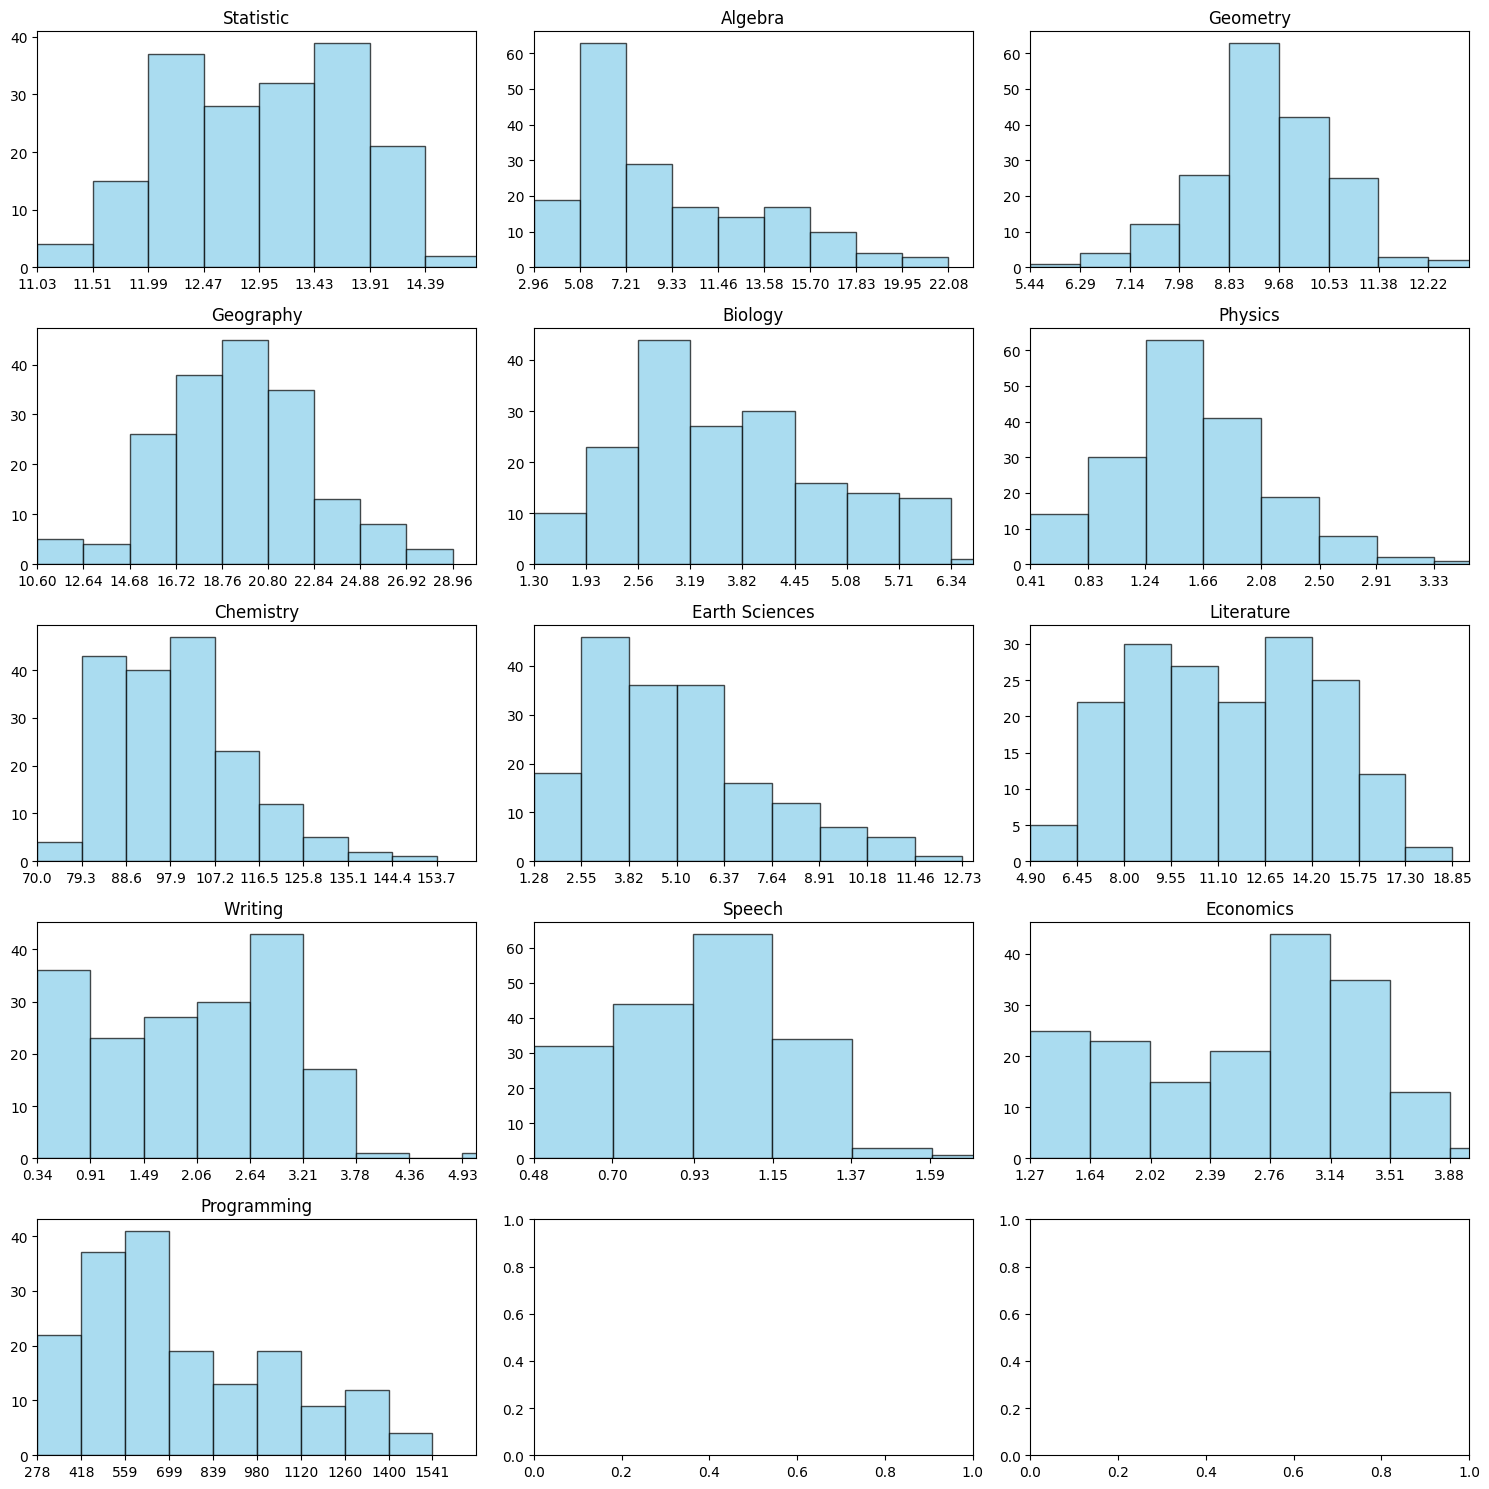

In [19]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))  # 5 rows, 3 columns for 13 subjects
axes = axes.flatten()

# Set binning and color
bins = np.arange(-4, 4, 0.5)  # Bins for scores ranging from 40 to 100
color = 'skyblue'

# Loop through each subject and plot histogram
for i, subject in enumerate(stdf.columns):
    bins = np.arange(stdf[subject].min(), stdf[subject].max() + 1, (stdf[subject].max() + 1- stdf[subject].min())/10)
    axes[i].hist(stdf[subject], bins=bins, edgecolor='black', color=color, alpha=0.7)
    axes[i].set_title(subject)  # Set title for each subplot
    axes[i].set_xticks(np.round(bins, 2))
    axes[i].set_xlim(stdf[subject].min(), stdf[subject].max())   # Set x-axis limits to score range

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

#### K mean clustering

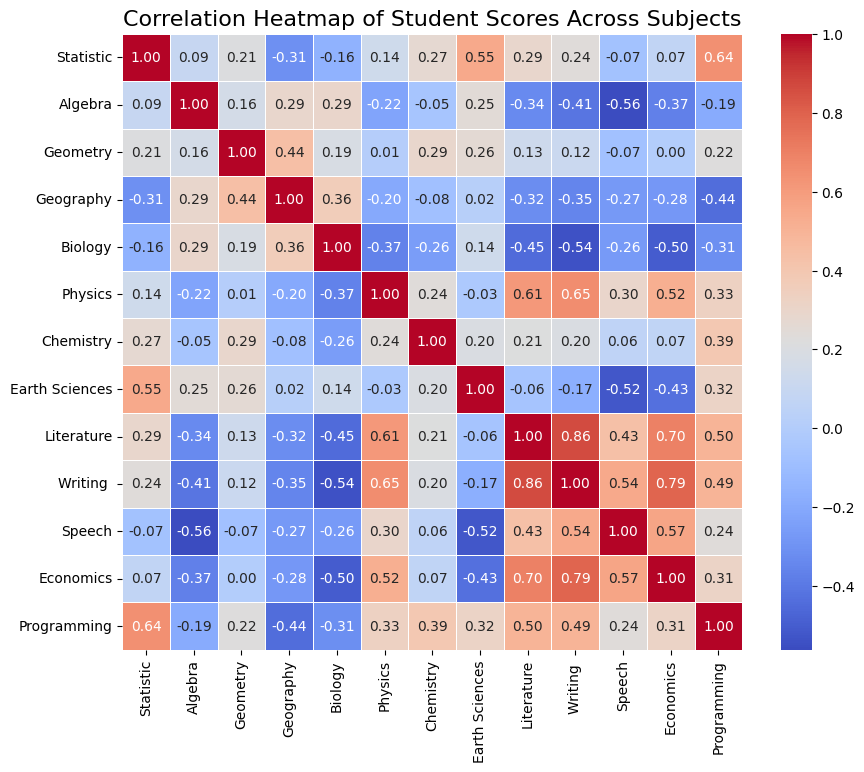

In [20]:
corr_matrix = norm_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Heatmap of Student Scores Across Subjects', fontsize=16)
plt.show()

We can see that there are 2 subsets of subjects that are correlated with each other:    
    - Literature, Writing, Speech, Economics (Humanitarian)
    - Earth Science, Algebra, Geometry, Geography, Biology (They are not seem to be highly correlated with any others)
    - Programming, Statistic, Physics, Chemistry (Natural Science)
=> We will cluster into 3 groups

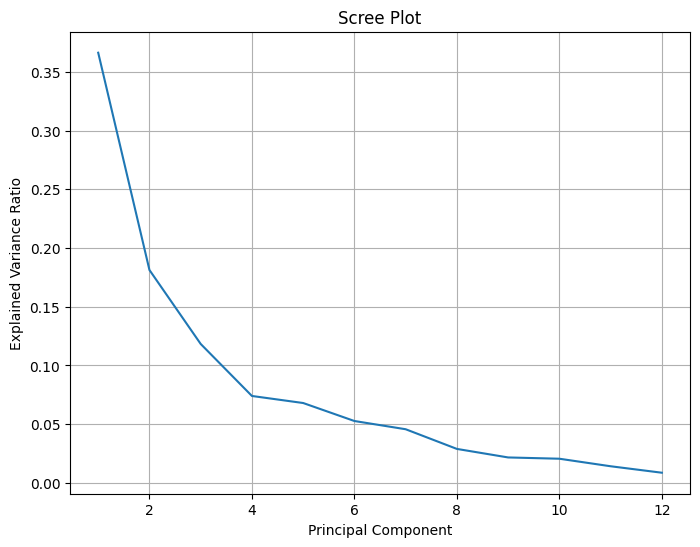

In [21]:
from sklearn.decomposition import PCA

# Assuming your DataFrame with mean values is named 'prst_mean'
prst_pca = PCA()
prst_pca.fit(norm_df.iloc[:, :-1].to_numpy())

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(prst_pca.explained_variance_ratio_) + 1), prst_pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [ ]:
# 2 components explained variance ratio
print(sum(prst_pca.explained_variance_ratio_[:2]))

0.5476044240794515


##### Clustering

In [35]:
# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(norm_df)  # Fit and assign clusters

/home/tminh/anaconda3/envs/tminh/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


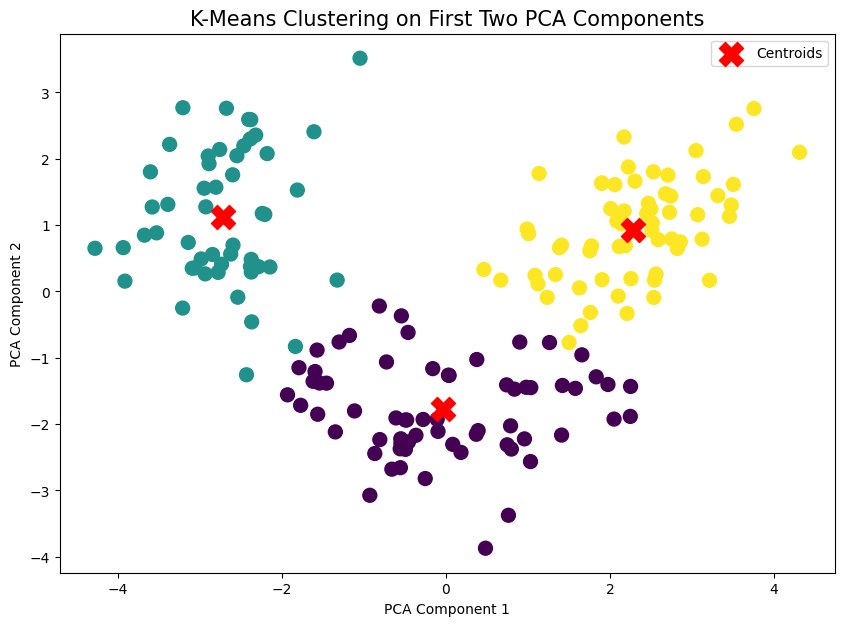

In [ ]:
# Perform PCA to reduce the data to 2 components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(norm_df)

# Visualize the results
plt.figure(figsize=(10, 7))

# Scatter plot of the PCA components, colored by their cluster labels
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=clusters, cmap='viridis', s=100)

# Mark the centroids of the clusters (in PCA space)
centroids = pca.transform(kmeans.cluster_centers_)  # Transform cluster centers to PCA space
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=300, marker='X', label='Centroids')

# Add labels and title
plt.title('K-Means Clustering on First Two PCA Components', fontsize=15)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

##### Verifying

In [38]:
cluster_0_df = norm_df[clusters == 0]

# Extract scores for cluster 1
cluster_1_df = norm_df[clusters == 1]

# Extract scores for cluster 2
cluster_2_df = norm_df[clusters == 2]


In [ ]:
cluster_0_df.describe()

# Based on mean, this group seem to be group of Literature, Writing, Speech, Economics

,Statistic,Algebra,Geometry,Geography,Biology,Physics,Chemistry,Earth Sciences,Literature,Writing,Speech,Economics,Programming
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,-0.926072,-0.394042,-0.494517,0.170602,-0.033534,0.058266,-0.491712,-0.901914,-0.075983,0.020813,0.461804,0.270764,-0.753846
std,0.658408,0.908663,1.093676,0.906694,0.978490,0.999384,0.960576,0.342511,0.849702,0.611364,0.885917,0.646633,0.454531
min,-2.434235,-1.432983,-3.679162,-2.671018,-1.868234,-2.069034,-2.088255,-1.634288,-1.914966,-1.465058,-1.173391,-1.330077,-1.493188
25%,-1.396613,-1.011081,-1.339744,-0.448909,-0.740141,-0.422075,-0.964842,-1.106553,-0.633101,-0.390814,-0.120430,-0.214247,-1.085572
50%,-0.927212,-0.652016,-0.462462,0.151661,-0.095517,-0.054137,-0.824415,-0.933525,-0.152402,0.000733,0.362177,0.322481,-0.802153
75%,-0.717217,-0.185231,0.195499,0.632117,0.549108,0.489009,-0.122282,-0.760497,0.424438,0.422399,1.151898,0.774463,-0.388168
max,1.061565,3.109192,2.023170,2.704083,2.402403,3.485073,3.599025,0.104643,1.962676,1.727556,3.301694,1.452436,0.442985


In [ ]:
cluster_1_df.describe()
# Based on mean, this group seem to be group of Algebra, Geometry, Geography, Biology, Earth Sciences

,Statistic,Algebra,Geometry,Geography,Biology,Physics,Chemistry,Earth Sciences,Literature,Writing,Speech,Economics,Programming
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,0.164907,0.871547,0.186898,0.524367,0.726064,-0.779706,-0.075473,0.941539,-0.979330,-1.215248,-1.164789,-1.292412,-0.407088
std,0.644629,0.981474,0.727499,0.723087,0.991342,0.720694,0.777521,1.014634,0.560010,0.325196,0.528161,0.388210,0.384443
min,-0.988975,-0.984151,-1.412851,-1.049479,-1.545922,-1.823742,-1.386122,-0.717240,-2.107246,-1.695971,-2.094732,-1.895054,-1.193845
25%,-0.272522,0.223205,-0.279695,0.076590,0.307374,-1.324398,-0.754202,0.121946,-1.362162,-1.455019,-1.612125,-1.527819,-0.722540
50%,0.135116,0.838105,0.049285,0.451946,0.871420,-0.860096,-0.192495,0.969783,-1.033684,-1.334543,-1.261138,-1.315952,-0.404091
75%,0.610693,1.408121,0.816907,0.977445,1.354888,-0.422075,0.439425,1.750572,-0.769299,-1.008253,-0.844341,-1.111148,-0.181176
max,1.654492,2.974543,1.803849,2.253656,2.160669,1.943238,1.633052,3.435432,0.808997,-0.441012,0.098937,-0.200123,0.423878


In [ ]:
cluster_2_df.describe()
# Based on mean, this group seem to be group of Programming, Statistic, Physics, Chemistry

,Statistic,Algebra,Geometry,Geography,Biology,Physics,Chemistry,Earth Sciences,Literature,Writing,Speech,Economics,Programming
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,0.835232,-0.303810,0.364706,-0.610191,-0.562090,0.580287,0.577587,0.171063,0.885237,0.977820,0.473984,0.779247,1.125185
std,0.690629,0.606499,0.896820,0.993782,0.587277,0.768283,0.923553,0.559831,0.546780,0.481883,0.525381,0.513809,0.741101
min,-1.779545,-0.885409,-1.193530,-2.490847,-1.545922,-0.597284,-0.754202,-1.063296,-0.152402,0.161368,-0.603037,-0.143625,-0.897687
25%,0.360552,-0.604889,-0.270557,-1.049479,-0.881153,0.121071,-0.087175,-0.241413,0.488531,0.653312,0.131842,0.364855,0.722424
50%,0.907156,-0.512878,0.286883,-0.749194,-0.578985,0.532811,0.404318,0.147900,0.849056,0.949482,0.493797,0.788587,1.036893
75%,1.345675,-0.353543,0.917429,-0.186160,-0.337251,0.883228,1.124005,0.493956,1.129464,1.223063,0.757038,1.180540,1.689714
max,2.259772,1.529305,3.156325,3.154511,1.113154,2.959447,4.371372,1.661895,2.539515,3.062832,1.546759,1.960915,2.971473
